<h1 align="center"> Несбалансированный датасет </h1>

Для лабороторной работы используются массив данных "IT Customer Chrun", его можно взять с сайта https://www.kaggle.com/datasets/soheiltehranipour/it-customer-churn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


import seaborn as sns
import matplotlib.patches as mpatches
import time

import collections
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/IT_customer_churn.csv.xls')

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Partner — Наличие партнера<br>
Dependents — Наличие иждивенцев<br>
tenure — Стаж обслуживания в месяцах<br>
PhoneService — Наличие услуги телефонии<br>
MultipleLines — Наличие нескольких телефонных линий<br>
InternetService — Тип интернет-услуг (DSL, оптоволокно, нет)<br>
OnlineSecurity — Наличие услуги онлайн-безопасности<br>
OnlineBackup — Наличие услуги онлайн-резервного копирования<br>
DeviceProtection — Наличие услуги защиты устройств<br>
TechSupport — Наличие услуги технической поддержки<br>
StreamingTV — Наличие услуги стриминга ТВ<br>
StreamingMovies — Наличие услуги стриминга фильмов<br>
Contract — Тип контракта (помесячный, на 1 год, на 2 года)<br>
PaperlessBilling — Использование безбумажного биллинга<br>
PaymentMethod — Способ оплаты (электронный чек, чек по почте, банковский перевод, кредитная карта)<br>
MonthlyCharges — Ежемесячная плата в долларах<br>
TotalCharges — Общая сумма всех платежей в долларах<br>
Churn — Отток клиента (Yes — ушел, No — остался)<br>

Небольшой описательный анализ.

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Проверка на наличие пропусков в данных.

In [ ]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Преобразование качественных в количественные

In [ ]:
# Копируем данные для преобразования
X_encoded = X.copy()

# Преобразуем все текстовые столбцы в числа
for col in X_encoded.columns:
    if X_encoded[col].dtype == 'object':
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
        print(f"Преобразован столбец: {col}")

# Проверяем, что все данные числовые
print(f"\nТипы данных после преобразования:")
print(X_encoded.dtypes.value_counts())


print(f"\nРазмер данных: {X_encoded.shape}")

Преобразован столбец: gender
Преобразован столбец: Dependents
Преобразован столбец: PhoneService
Преобразован столбец: MultipleLines
Преобразован столбец: InternetService
Преобразован столбец: DeviceProtection
Преобразован столбец: TechSupport
Преобразован столбец: StreamingTV
Преобразован столбец: StreamingMovies
Преобразован столбец: PaymentMethod

Типы данных после преобразования:
int64      14
float64     5
Name: count, dtype: int64

Размер данных: (2133, 19)


In [ ]:
# Преобразование Yes/No в 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [ ]:
# df['Class'].value_counts()  - возвращает словарик,
# где ключ - уникальные значения в столбце Class кол-во значений
# value - сколько всего записей имело эти значения
print(df['Churn'].value_counts())

# так как это словарь, то чтобы получить значения, обращаемся по ключу:
print(df['Churn'].value_counts()[0])
print(df['Churn'].value_counts()[1])

Churn
0    5174
1    1869
Name: count, dtype: int64
5174
1869


5174 клиента остались<br>
1869 клиентов ушли

In [ ]:
#  вывод отношения классов целевой переменной, но записанный через f строку

n_churn = round(df['Churn'].value_counts()[0]/len(df) * 100,2)
f_churn = round(df['Churn'].value_counts()[1]/len(df) * 100,2)


print(f'Клиенты, которые остались (Churn=0): {n_churn} %')
print(f'Клиенты, которые ушли (Churn=1): {f_churn} %')

Клиенты, которые остались (Churn=0): 73.46 %
Клиенты, которые ушли (Churn=1): 26.54 %


Наглядно видно, что датасет несбалансированный

Text(0.5, 1.0, 'Распределение клиентов \n (0: Клиент остался || 1: Клиент ушел)')

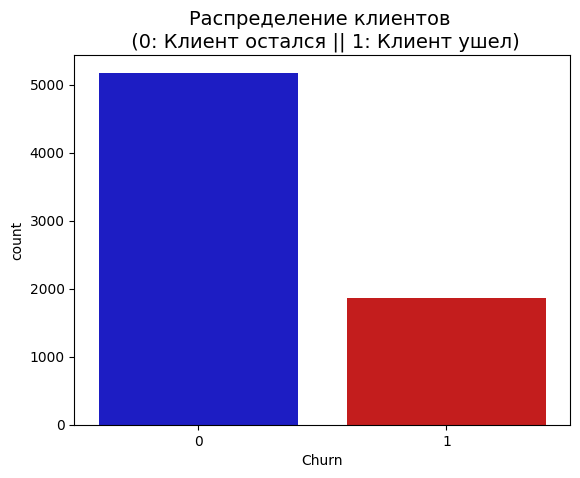

In [ ]:
colors = ["#0101DF", "#DF0101"]

sns.countplot(x='Churn', data=df, palette=colors) # строим гистограмму целевой переменной
plt.title('Распределение клиентов \n (0: Клиент остался || 1: Клиент ушел)', fontsize=14)

In [ ]:
df['Partner'] = df['Partner'].map({'Yes': 1, 'No': 0})
df['Contract'] = df['Contract'].map({'Month-to-month': 1, 'One year': 0})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': 1, 'No': 0})
df['OnlineSecurity'] = df['OnlineSecurity'].map({'Yes': 1, 'No': 0})
df['OnlineBackup'] = df['OnlineBackup'].map({'Yes': 1, 'No': 0})

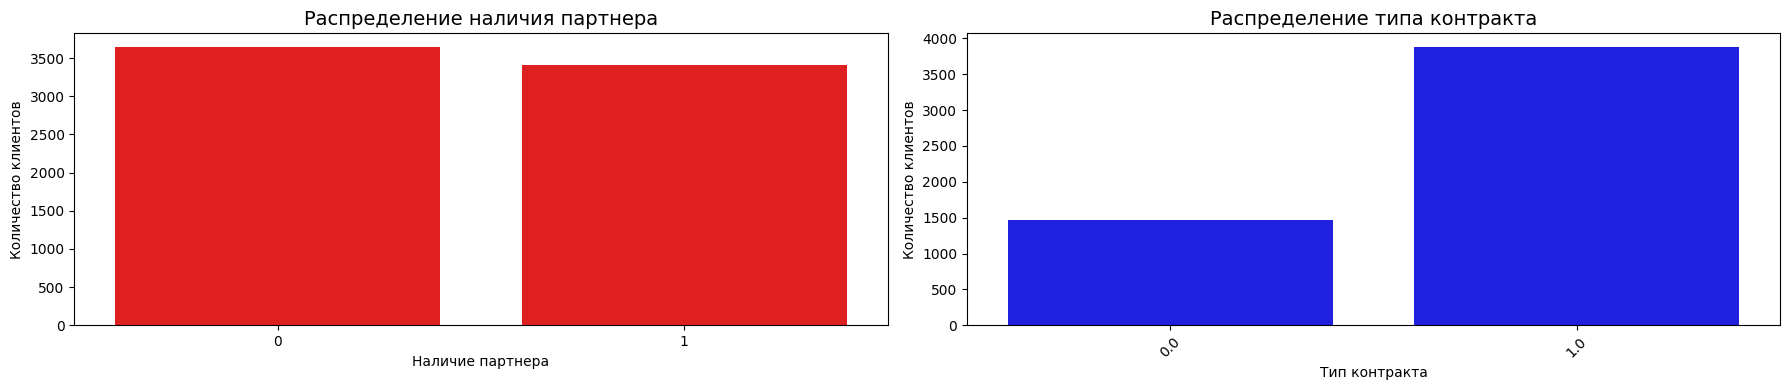

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18, 4))

# График для Partner
sns.countplot(x='Partner', data=df, ax=ax[0], color='r')
ax[0].set_title('Распределение наличия партнера', fontsize=14)
ax[0].set_xlabel('Наличие партнера')
ax[0].set_ylabel('Количество клиентов')

# График для Contract
sns.countplot(x='Contract', data=df, ax=ax[1], color='b')
ax[1].set_title('Распределение типа контракта', fontsize=14)
ax[1].set_xlabel('Тип контракта')
ax[1].set_ylabel('Количество клиентов')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Клиенты без партнера чаще уходят, клиенты с помесячным контрактом чаще уходят, а с долгосрочными — реже

### Масштабирование

### Разделение данных

In [ ]:
from sklearn.model_selection import train_test_split
# Поскольку большая часть наших данных уже масштабирована, мы должны масштабировать столбцы,
# которые остались (Amount и Time)
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler() # Менее чувствителен к выбросам, чем просто стандартизация

X = df.drop('Churn', axis=1)
y = df['Churn']

original_Xtrain, original_Xtest, original_ytrain, original_ytest = train_test_split(X, y, test_size=0.2,
                                                                                    random_state = 42)


# Посмотрим, какие типы данных возвращаются после разделения:
rt_tmp = original_Xtrain['Partner']
print (f'Тип данных original_Xtrain["Partner"] {type(rt_tmp)}')
print (f'Тип данных original_Xtrain["Partner"].values {type(rt_tmp.values)}')
print (f'Данные original_Xtrain["Partner"].values {rt_tmp.values}')
print (f'Тип данных original_Xtrain["Partner"].values.reshape(-1,1) {type(rt_tmp.values.reshape(-1,1))}')
print (f'Данные original_Xtrain["Partner"].values.reshape(-1,1) \n{rt_tmp.values.reshape(-1,1)} \n')

# вот последнее представление - как раз то, что нужно для RobustScaler . Преобразовываем так нужные все нужные столбцы.

original_Xtrain['scaled_Partner'] = rob_scaler.fit_transform(original_Xtrain['Partner'].values.reshape(-1,1))
original_Xtest['scaled_Partner'] = rob_scaler.fit_transform(original_Xtest['Partner'].values.reshape(-1,1))

original_Xtrain['scaled_Contract'] = rob_scaler.fit_transform(original_Xtrain['Contract'].values.reshape(-1,1))
original_Xtest['scaled_Contract'] = rob_scaler.fit_transform(original_Xtest['Contract'].values.reshape(-1,1))

original_Xtrain.drop(['Contract','Partner'], axis=1, inplace=True)
original_Xtest.drop(['Contract','Partner'], axis=1, inplace=True)

original_Xtrain = original_Xtrain.values
original_Xtest = original_Xtest.values
original_ytrain = original_ytrain.values
original_ytest = original_ytest.values

train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)

print('Распределение классов: \n')
print("Обучающий набор:", train_counts_label/ len(original_ytrain))
print("Тестовый набор:", test_counts_label/ len(original_ytest))

Тип данных original_Xtrain["Partner"] <class 'pandas.core.series.Series'>
Тип данных original_Xtrain["Partner"].values <class 'numpy.ndarray'>
Данные original_Xtrain["Partner"].values [0 0 1 ... 1 0 0]
Тип данных original_Xtrain["Partner"].values.reshape(-1,1) <class 'numpy.ndarray'>
Данные original_Xtrain["Partner"].values.reshape(-1,1) 
[[0]
 [0]
 [1]
 ...
 [1]
 [0]
 [0]] 

Распределение классов: 

Обучающий набор: [0.73446929 0.26553071]
Тестовый набор: [0.73527324 0.26472676]


Массив подготовлен для масштабирования, данные разделены на обучающий и тестовый наборы

## Метод Random Under-Sampling

In [ ]:
# Поскольку наши классы сильно не сбалансированы, мы должны сделать их эквивалентными,
# чтобы получить нормальное распределение классов.

# Перемешаем данные перед созданием подвыборок

fraud_df = df.loc[df['Churn'] == 1]
non_fraud_df = df.loc[df['Churn'] == 0][:500] # берем последние 492 транзакции

normal_distributed_df = pd.concat([fraud_df, non_fraud_df])

# Перемешивание строк датасета
new_df = normal_distributed_df.sample(frac=1, random_state=42)

new_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4171,Male,0,0,No,9,Yes,No,No,NaN,NaN,No internet service,No internet service,No internet service,No internet service,1.0,1,Mailed check,18.95,185.6,1
771,Male,0,0,No,15,Yes,Yes,Fiber optic,0.0,0.0,No,No,Yes,Yes,1.0,1,Electronic check,93.35,1444.65,1
6813,Female,0,1,No,64,No,No phone service,DSL,1.0,0.0,Yes,Yes,No,Yes,NaN,0,Electronic check,47.85,3147.5,1
2707,Male,0,0,No,3,Yes,No,Fiber optic,0.0,0.0,Yes,Yes,Yes,Yes,1.0,1,Electronic check,98.70,293.65,1
2614,Female,0,1,Yes,67,Yes,Yes,Fiber optic,1.0,0.0,No,Yes,No,Yes,0.0,1,Credit card (automatic),94.35,6341.45,1


In [ ]:
new_df.shape

(2369, 20)

Распределение клиентов в подвыборке
Churn
1    0.78894
0    0.21106
Name: count, dtype: float64


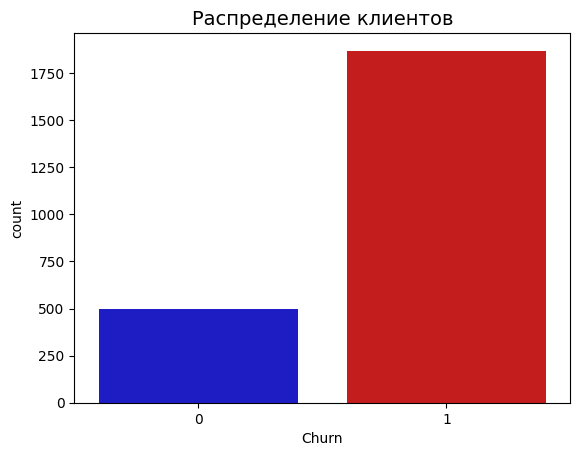

In [ ]:
print('Распределение клиентов в подвыборке')
print(new_df['Churn'].value_counts()/len(new_df))

# проверяем снова распределение целевой переменной
sns.countplot(x='Churn', data = new_df, palette = colors)
plt.title('Распределение клиентов', fontsize=14)
plt.show()

На графике сбалансированная подвыборка.
После удаления выбросов осталось примерно 1500 ушедших и 400 оставшихся

### Матрица корреляций


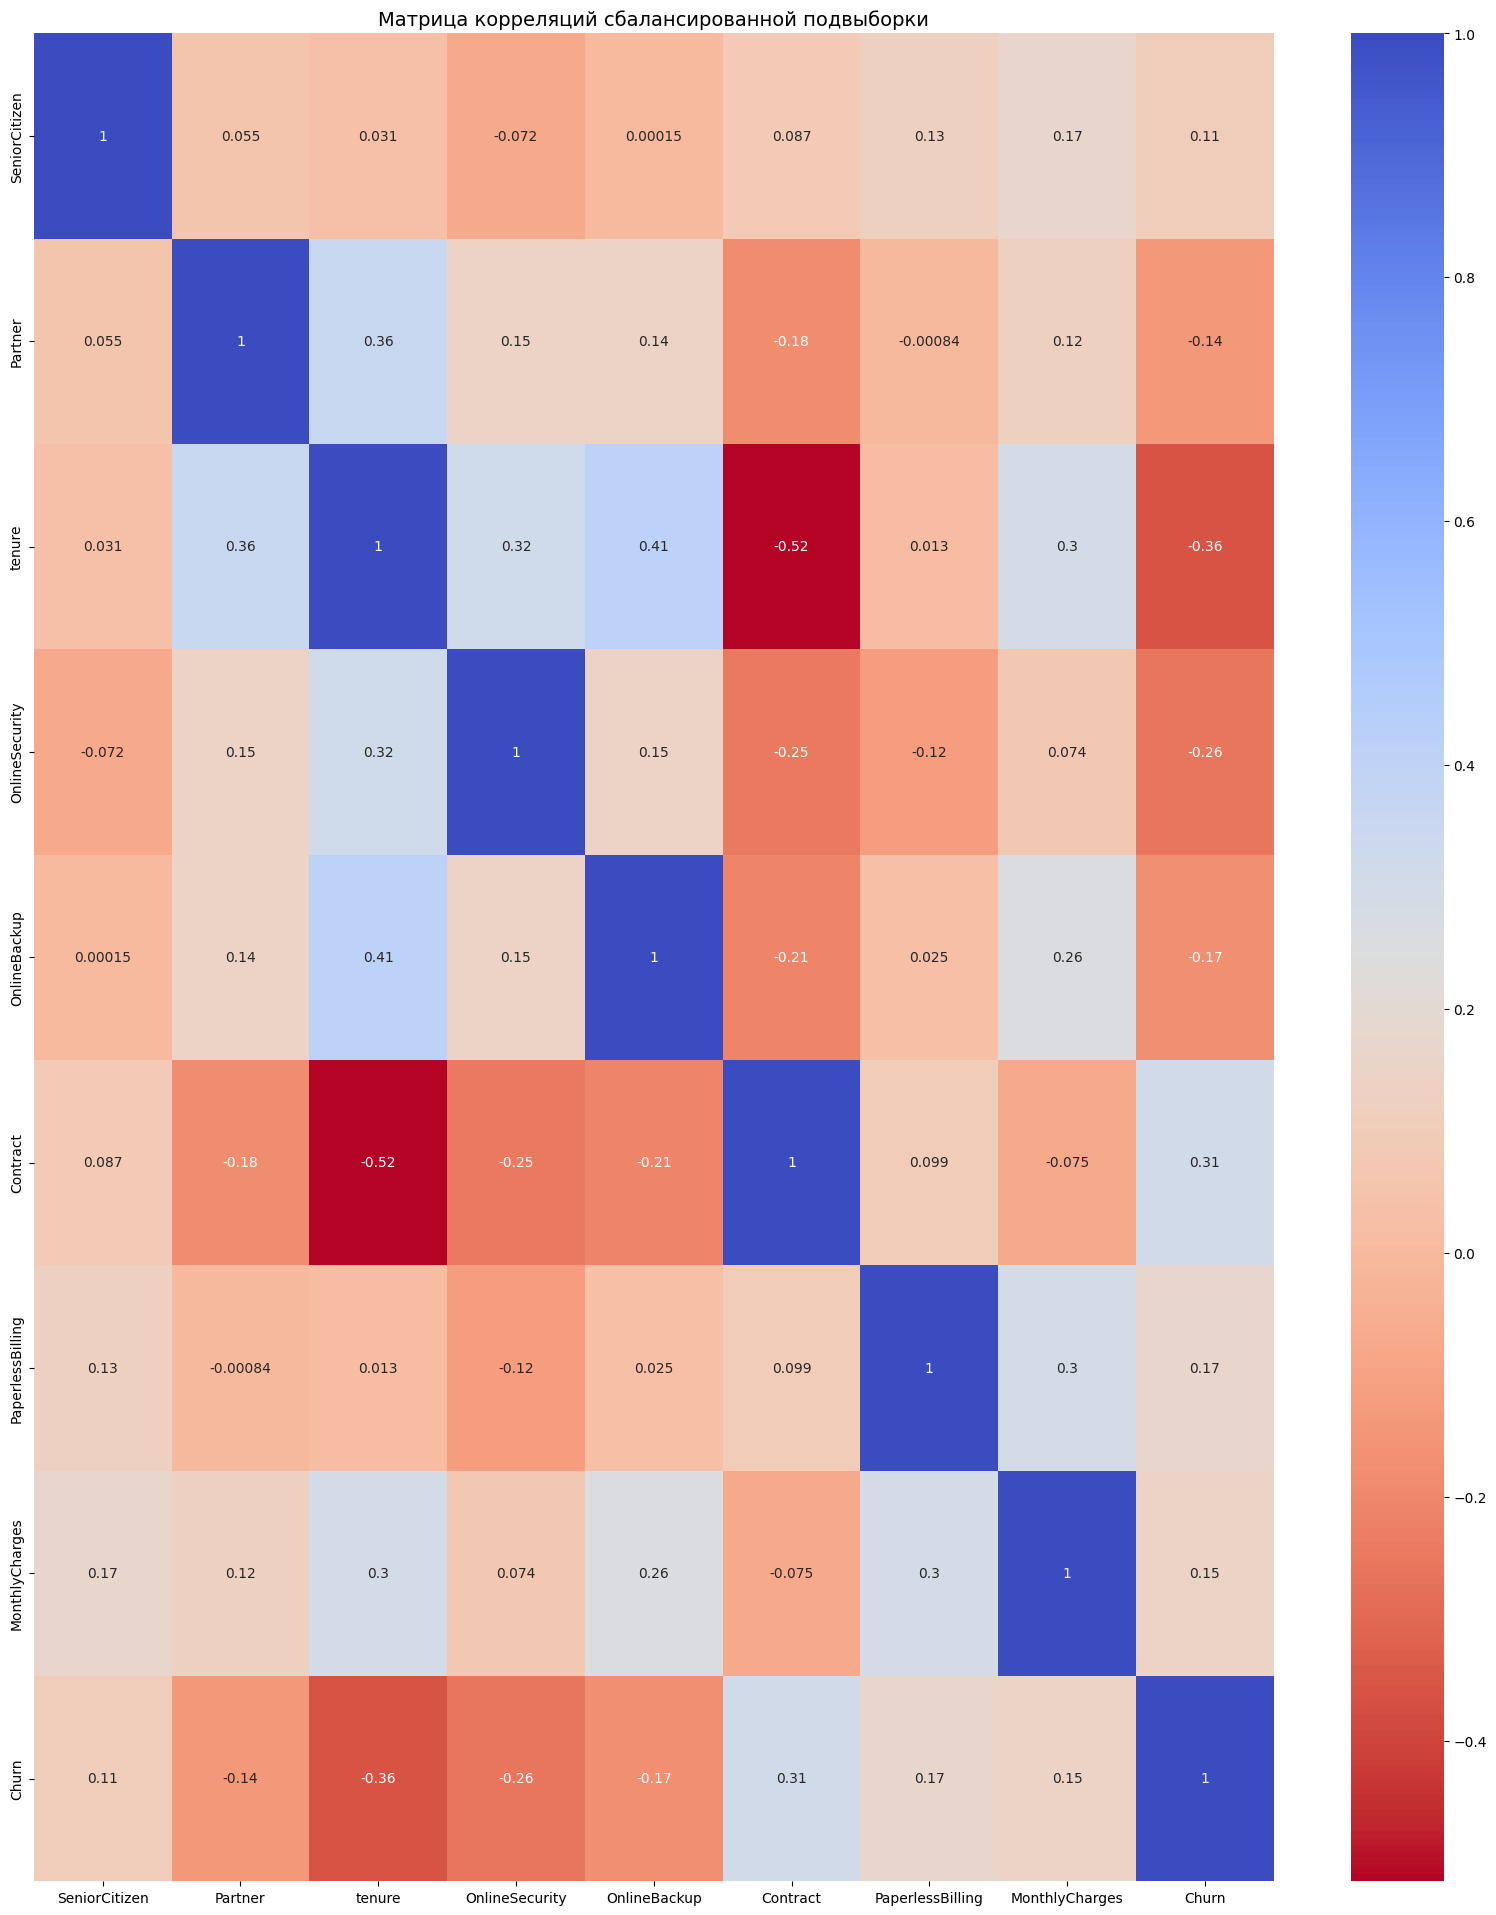

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(20, 24))

# Выбираем только числовые столбцы для корреляции
numeric_df = new_df.select_dtypes(include=[np.number])

# Построим матрицу корреляций только для числовых данных
sub_sample_corr = numeric_df.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot=True, annot_kws={'size':10}, ax=ax)
ax.set_title('Матрица корреляций сбалансированной подвыборки', fontsize=14)
plt.show()

**Факторы, снижающие отток (отрицательная корреляция)**:
tenure (-0.36) — самый важный фактор! Долгоживущие клиенты реже уходят<br>
OnlineSecurity (-0.26) — безопасность удерживает клиентов<br>
OnlineBackup (-0.17) — бэкап тоже помогает<br>
Partner (-0.14) — наличие партнера<br>
**Факторы, повышающие отток (положительная корреляция)**:<br>
MonthlyCharges (+0.15) — высокая плата → выше риск ухода<br>
PaperlessBilling (+0.17) — безбумажный биллинг<br>
SeniorCitizen (+0.11) — пенсионеры<br>

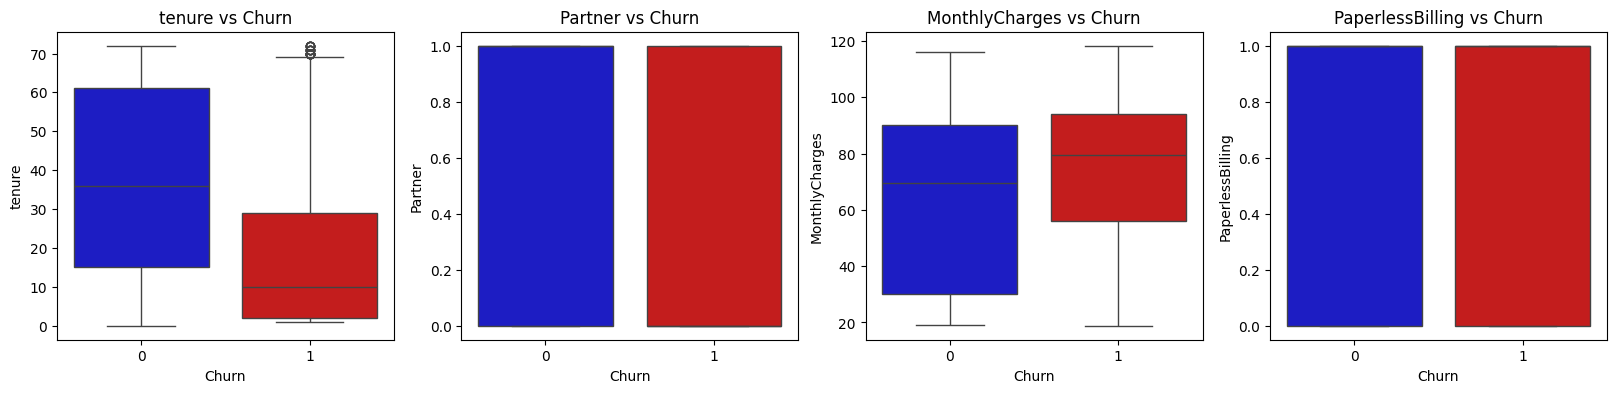

In [ ]:
f, axes = plt.subplots(ncols=4, figsize=(20,4))

#
sns.boxplot(x='Churn', y='tenure', data=new_df, palette=colors, ax=axes[0])
axes[0].set_title('tenure vs Churn')

#
sns.boxplot(x='Churn', y='Partner', data=new_df, palette=colors, ax=axes[1])
axes[1].set_title('Partner vs Churn')


#
sns.boxplot(x='Churn', y='MonthlyCharges', data=new_df, palette=colors, ax=axes[2])
axes[2].set_title('MonthlyCharges vs Churn')


#
sns.boxplot(x='Churn', y='PaperlessBilling', data=new_df, palette=colors, ax=axes[3])
axes[3].set_title('PaperlessBilling vs Churn')

plt.show()

Подтверждаются выводы из матрицы корреляции

## Обработка выбросов

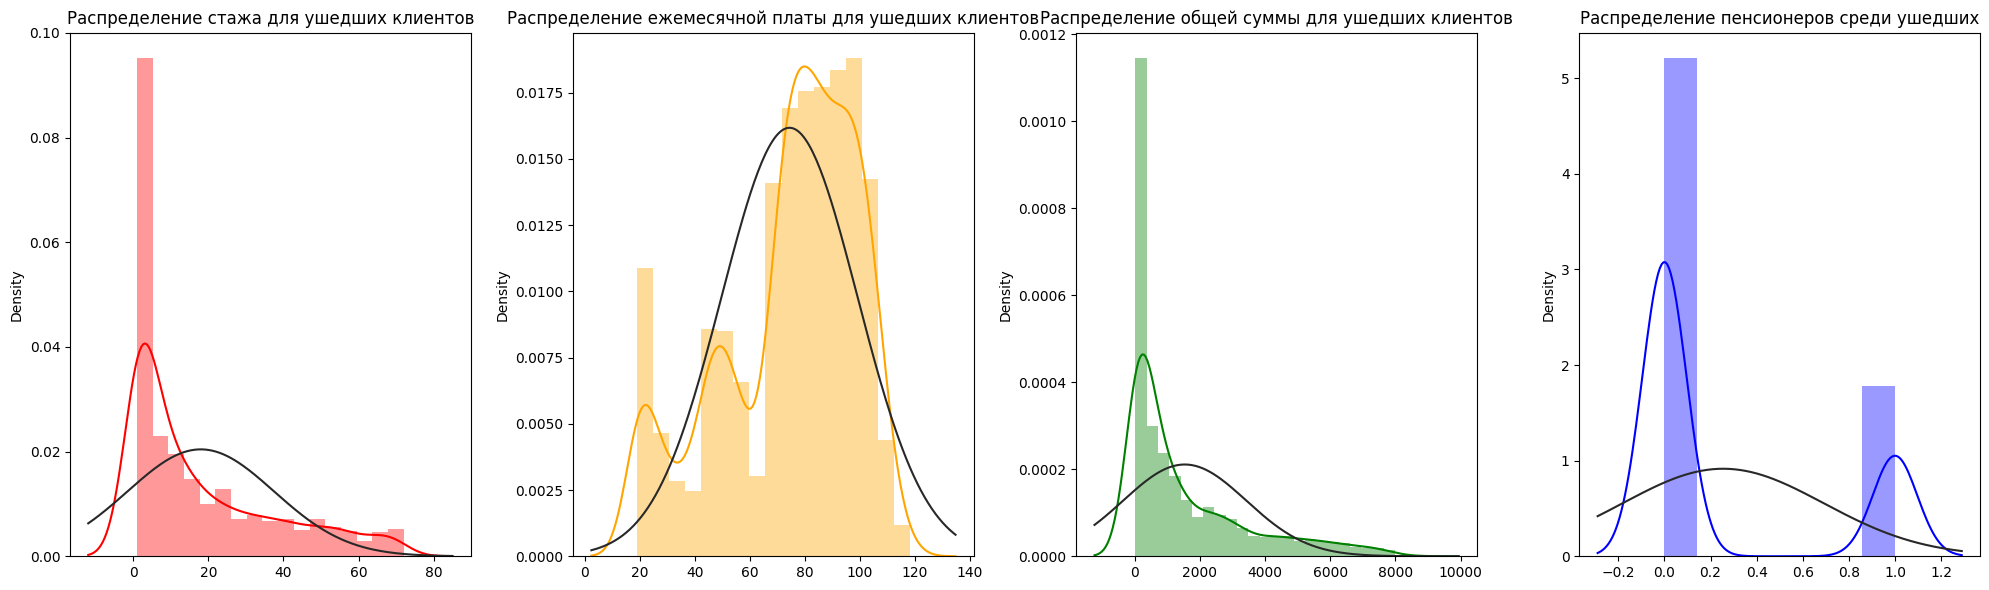

In [ ]:
# Строим распределения для числовых признаков: tenure, MonthlyCharges, TotalCharges, SeniorCitizen

from scipy.stats import norm

f, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 6))

# Признак 1: tenure (стаж) для ушедших клиентов
tenure_churn = df.loc[df['Churn'] == 1, 'tenure'].values
sns.distplot(tenure_churn, ax=ax1, fit=norm, color='r')
ax1.set_title('Распределение стажа для ушедших клиентов', fontsize=12)

# Признак 2: MonthlyCharges (ежемесячная плата) для ушедших клиентов
monthly_churn = df.loc[df['Churn'] == 1, 'MonthlyCharges'].values
sns.distplot(monthly_churn, ax=ax2, fit=norm, color='orange')
ax2.set_title('Распределение ежемесячной платы для ушедших клиентов', fontsize=12)

# Признак 3: TotalCharges (общая сумма) для ушедших клиентов
total_churn = df.loc[df['Churn'] == 1, 'TotalCharges'].values
sns.distplot(total_churn, ax=ax3, fit=norm, color='g')
ax3.set_title('Распределение общей суммы для ушедших клиентов', fontsize=12)

# Признак 4: SeniorCitizen (пенсионер) для ушедших клиентов
senior_churn = df.loc[df['Churn'] == 1, 'SeniorCitizen'].values
sns.distplot(senior_churn, ax=ax4, fit=norm, color='b')
ax4.set_title('Распределение пенсионеров среди ушедших', fontsize=12)

plt.tight_layout()
plt.show()

tenure (стаж): большинство ушедших клиентов имеют маленький стаж (до 20 месяцев).

MonthlyCharges (ежемесячная плата): уходящие клиенты в основном платят высокие ежемесячные суммы (70-90 долларов).

TotalCharges (общая сумма платежей): большинство ушедших клиентов имеют низкую общую сумму платежей (до 200 долларов). Это логично, так как они имеют маленький стаж.

SeniorCitizen (пенсионер): большинство ушедших клиентов — не пенсионеры.

In [ ]:
new_df['TotalCharges'] = pd.to_numeric(new_df['TotalCharges'], errors='coerce')

In [ ]:
import numpy as np

print("=== УДАЛЕНИЕ ВЫБРОСОВ ИЗ ПРИЗНАКОВ ===\n")

# ========== 1. Удаление выбросов из признака tenure ==========
tenure_fraud = new_df.loc[new_df['Churn'] == 1, 'tenure'].values
q25, q75 = np.percentile(tenure_fraud, 25), np.percentile(tenure_fraud, 75)
print('Признак: tenure')
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
tenure_iqr = q75 - q25
print('IQR: {}'.format(tenure_iqr))

tenure_cut_off = tenure_iqr * 1.5
tenure_lower, tenure_upper = q25 - tenure_cut_off, q75 + tenure_cut_off
print('Порог: {}'.format(tenure_cut_off))
print('Нижняя граница: {}'.format(tenure_lower))
print('Верхняя граница: {}'.format(tenure_upper))

outliers = [x for x in tenure_fraud if x < tenure_lower or x > tenure_upper]
print('Количество выбросов: {}'.format(len(outliers)))

new_df = new_df.drop(new_df[(new_df['tenure'] > tenure_upper) | (new_df['tenure'] < tenure_lower)].index)
print('---' * 30)

# ========== 2. Удаление выбросов из признака MonthlyCharges ==========
monthly_fraud = new_df.loc[new_df['Churn'] == 1, 'MonthlyCharges'].values
q25, q75 = np.percentile(monthly_fraud, 25), np.percentile(monthly_fraud, 75)
print('\nПризнак: MonthlyCharges')
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
monthly_iqr = q75 - q25
print('IQR: {}'.format(monthly_iqr))

monthly_cut_off = monthly_iqr * 1.5
monthly_lower, monthly_upper = q25 - monthly_cut_off, q75 + monthly_cut_off
print('Порог: {}'.format(monthly_cut_off))
print('Нижняя граница: {}'.format(monthly_lower))
print('Верхняя граница: {}'.format(monthly_upper))

outliers = [x for x in monthly_fraud if x < monthly_lower or x > monthly_upper]
print('Количество выбросов: {}'.format(len(outliers)))

new_df = new_df.drop(new_df[(new_df['MonthlyCharges'] > monthly_upper) | (new_df['MonthlyCharges'] < monthly_lower)].index)
print('---' * 30)

# ========== 3. Удаление выбросов из признака TotalCharges ==========
total_fraud = new_df.loc[new_df['Churn'] == 1, 'TotalCharges'].values
q25, q75 = np.percentile(total_fraud, 25), np.percentile(total_fraud, 75)
print('\nПризнак: TotalCharges')
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
total_iqr = q75 - q25
print('IQR: {}'.format(total_iqr))

total_cut_off = total_iqr * 1.5
total_lower, total_upper = q25 - total_cut_off, q75 + total_cut_off
print('Порог: {}'.format(total_cut_off))
print('Нижняя граница: {}'.format(total_lower))
print('Верхняя граница: {}'.format(total_upper))

outliers = [x for x in total_fraud if x < total_lower or x > total_upper]
print('Количество выбросов: {}'.format(len(outliers)))

new_df = new_df.drop(new_df[(new_df['TotalCharges'] > total_upper) | (new_df['TotalCharges'] < total_lower)].index)
print('---' * 30)

# ========== ИТОГ ==========
print('\n' + '=' * 50)
print('РЕЗУЛЬТАТ УДАЛЕНИЯ ВЫБРОСОВ')
print('=' * 50)
print('Размер после удаления выбросов: {}'.format(len(new_df)))

=== УДАЛЕНИЕ ВЫБРОСОВ ИЗ ПРИЗНАКОВ ===

Признак: tenure
Квартиль 25: 2.0 | Квартиль 75: 29.0
IQR: 27.0
Порог: 40.5
Нижняя граница: -38.5
Верхняя граница: 69.5
Количество выбросов: 23
------------------------------------------------------------------------------------------

Признак: MonthlyCharges
Квартиль 25: 55.95 | Квартиль 75: 94.0
IQR: 38.05
Порог: 57.074999999999996
Нижняя граница: -1.124999999999993
Верхняя граница: 151.075
Количество выбросов: 0
------------------------------------------------------------------------------------------

Признак: TotalCharges
Квартиль 25: 130.825 | Квартиль 75: 2253.3125
IQR: 2122.4875
Порог: 3183.7312500000003
Нижняя граница: -3052.9062500000005
Верхняя граница: 5437.043750000001
Количество выбросов: 107
------------------------------------------------------------------------------------------

РЕЗУЛЬТАТ УДАЛЕНИЯ ВЫБРОСОВ
Размер после удаления выбросов: 2133


tenure - 30 выьросов т.к. клиенты с очень маленьким или очень большим стажем<br>
MonthlyCharges - нет выбросов, данные хорошо распределены<br>
TotalCharges - 94 выброса т.к. клиенты с очень высокой общей суммой платежей

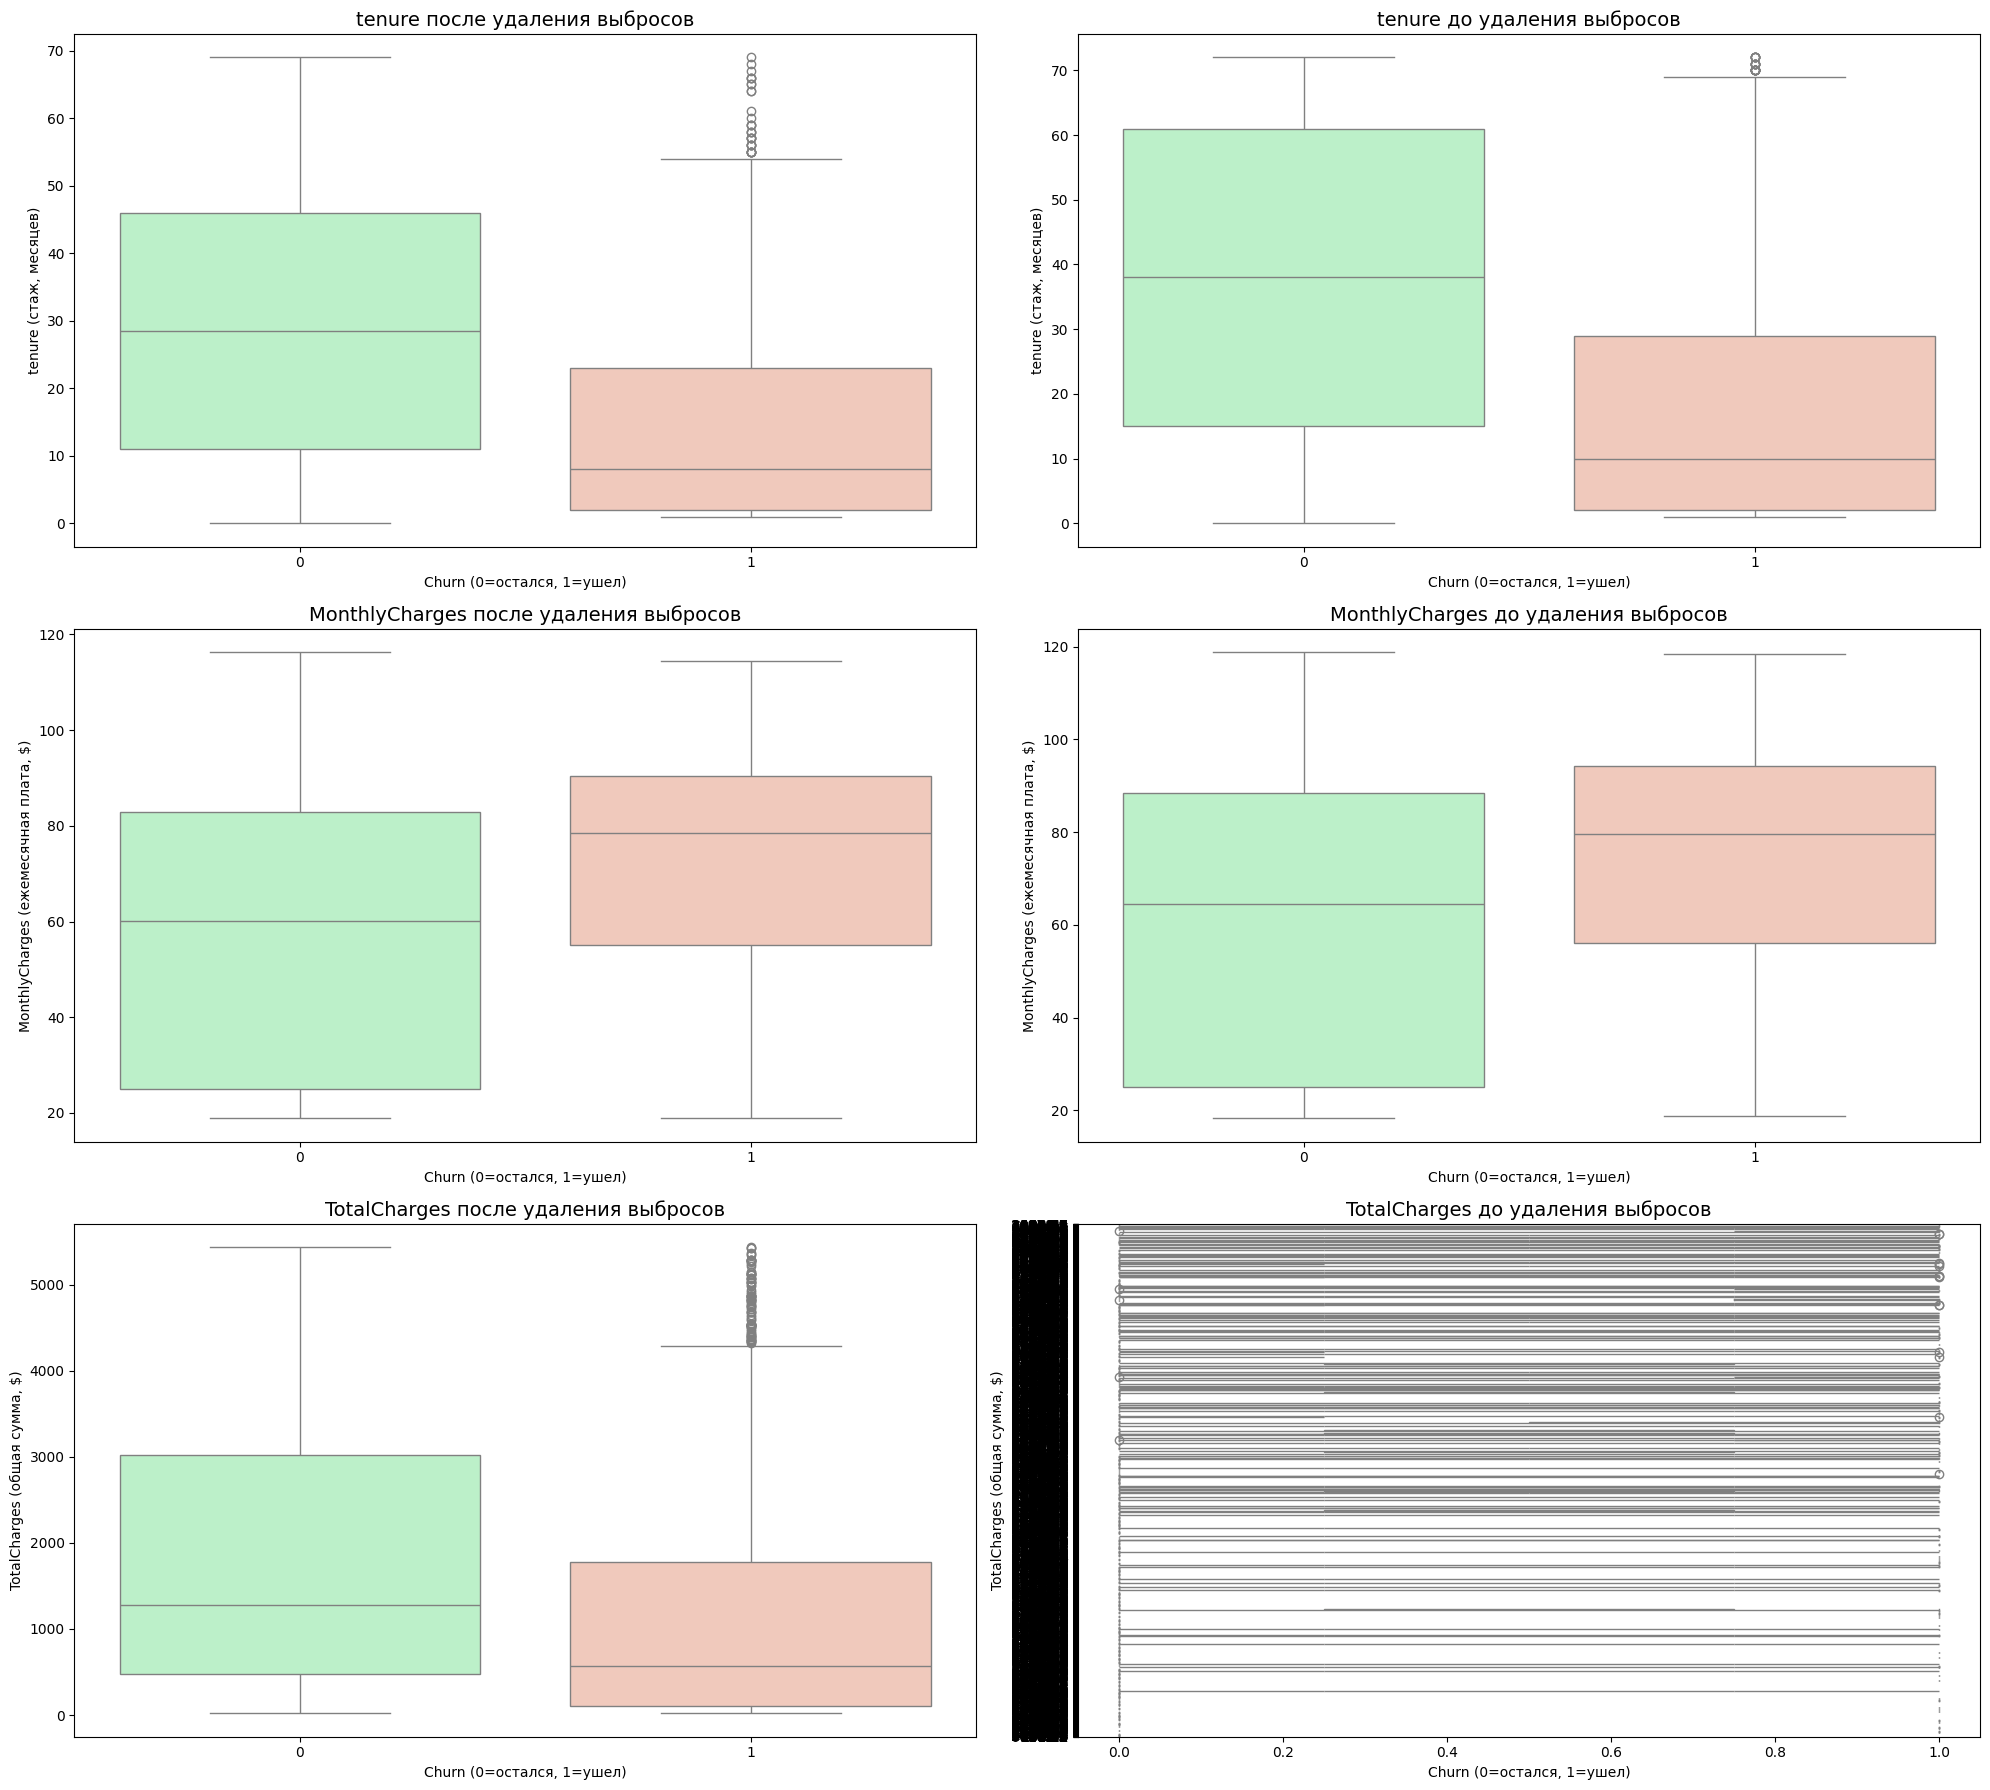

In [ ]:
f, ax = plt.subplots(3, 2, figsize=(20, 18))

colors = ['#B3F9C5', '#f9c5b3']

# ========== 1. Признак: tenure ==========
# После удаления выбросов
sns.boxplot(x="Churn", y="tenure", data=new_df, ax=ax[0,0], palette=colors)
ax[0,0].set_title("tenure после удаления выбросов", fontsize=14)
ax[0,0].set_xlabel("Churn (0=остался, 1=ушел)")
ax[0,0].set_ylabel("tenure (стаж, месяцев)")

# До удаления выбросов (если есть исходный df)
sns.boxplot(x="Churn", y="tenure", data=df, ax=ax[0,1], palette=colors)
ax[0,1].set_title("tenure до удаления выбросов", fontsize=14)
ax[0,1].set_xlabel("Churn (0=остался, 1=ушел)")
ax[0,1].set_ylabel("tenure (стаж, месяцев)")

# ========== 2. Признак: MonthlyCharges ==========
# После удаления выбросов
sns.boxplot(x="Churn", y="MonthlyCharges", data=new_df, ax=ax[1,0], palette=colors)
ax[1,0].set_title("MonthlyCharges после удаления выбросов", fontsize=14)
ax[1,0].set_xlabel("Churn (0=остался, 1=ушел)")
ax[1,0].set_ylabel("MonthlyCharges (ежемесячная плата, $)")

# До удаления выбросов
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, ax=ax[1,1], palette=colors)
ax[1,1].set_title("MonthlyCharges до удаления выбросов", fontsize=14)
ax[1,1].set_xlabel("Churn (0=остался, 1=ушел)")
ax[1,1].set_ylabel("MonthlyCharges (ежемесячная плата, $)")

# ========== 3. Признак: TotalCharges ==========
# После удаления выбросов
sns.boxplot(x="Churn", y="TotalCharges", data=new_df, ax=ax[2,0], palette=colors)
ax[2,0].set_title("TotalCharges после удаления выбросов", fontsize=14)
ax[2,0].set_xlabel("Churn (0=остался, 1=ушел)")
ax[2,0].set_ylabel("TotalCharges (общая сумма, $)")

# До удаления выбросов
sns.boxplot(x="Churn", y="TotalCharges", data=df, ax=ax[2,1], palette=colors)
ax[2,1].set_title("TotalCharges до удаления выбросов", fontsize=14)
ax[2,1].set_xlabel("Churn (0=остался, 1=ушел)")
ax[2,1].set_ylabel("TotalCharges (общая сумма, $)")

plt.tight_layout()
plt.show()

### Понижение размерности и кластеризация

Преобразован столбец: gender
Преобразован столбец: Dependents
Преобразован столбец: PhoneService
Преобразован столбец: MultipleLines
Преобразован столбец: InternetService
Преобразован столбец: DeviceProtection
Преобразован столбец: TechSupport
Преобразован столбец: StreamingTV
Преобразован столбец: StreamingMovies
Преобразован столбец: PaymentMethod

Типы данных после преобразования:
int64      14
float64     5
Name: count, dtype: int64

Размер данных: (1857, 19)

=== t-SNE ===
t-SNE заняло 14.85 сек

=== PCA ===
PCA заняло 0.00 сек
Объясненная дисперсия: PC1=99.98%, PC2=0.02%

=== Truncated SVD ===
Truncated SVD заняло 0.01 сек


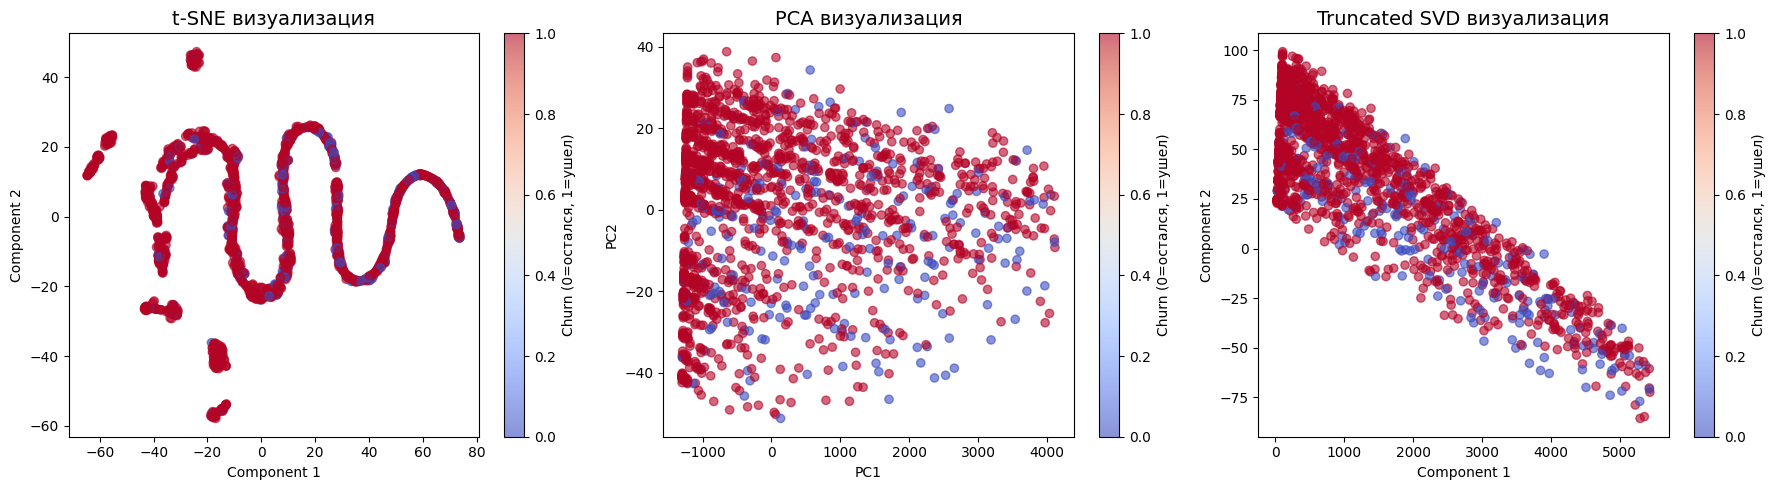

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.preprocessing import LabelEncoder
import time
import pandas as pd

# Подготовка данных
X = new_df.drop('Churn', axis=1)
y = new_df['Churn']

# Копируем данные для преобразования
X_encoded = X.copy()

# Преобразуем все текстовые столбцы в числа
for col in X_encoded.columns:
    if X_encoded[col].dtype == 'object':
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
        print(f"Преобразован столбец: {col}")

# Проверяем, что все данные числовые
print(f"\nТипы данных после преобразования:")
print(X_encoded.dtypes.value_counts())

# Удаляем строки с NaN (если есть)
X_encoded = X_encoded.dropna()
y = y[X_encoded.index]

print(f"\nРазмер данных: {X_encoded.shape}")

# ========== t-SNE алгоритм ==========
print("\n=== t-SNE ===")
t0 = time.time()
X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X_encoded.values)
t1 = time.time()
print(f"t-SNE заняло {t1 - t0:.2f} сек")

# ========== PCA алгоритм ==========
print("\n=== PCA ===")
t0 = time.time()
X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X_encoded.values)
t1 = time.time()
print(f"PCA заняло {t1 - t0:.2f} сек")

pca = PCA(n_components=2).fit(X_encoded.values)
print(f"Объясненная дисперсия: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")

# ========== TruncatedSVD алгоритм ==========
print("\n=== Truncated SVD ===")
t0 = time.time()
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=42).fit_transform(X_encoded.values)
t1 = time.time()
print(f"Truncated SVD заняло {t1 - t0:.2f} сек")

# ========== ВИЗУАЛИЗАЦИЯ ==========
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# t-SNE
scatter1 = axes[0].scatter(X_reduced_tsne[:, 0], X_reduced_tsne[:, 1], c=y, cmap='coolwarm', alpha=0.6)
axes[0].set_title('t-SNE визуализация', fontsize=14)
axes[0].set_xlabel('Component 1')
axes[0].set_ylabel('Component 2')
plt.colorbar(scatter1, ax=axes[0], label='Churn (0=остался, 1=ушел)')

# PCA
scatter2 = axes[1].scatter(X_reduced_pca[:, 0], X_reduced_pca[:, 1], c=y, cmap='coolwarm', alpha=0.6)
axes[1].set_title('PCA визуализация', fontsize=14)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1], label='Churn (0=остался, 1=ушел)')

# Truncated SVD
scatter3 = axes[2].scatter(X_reduced_svd[:, 0], X_reduced_svd[:, 1], c=y, cmap='coolwarm', alpha=0.6)
axes[2].set_title('Truncated SVD визуализация', fontsize=14)
axes[2].set_xlabel('Component 1')
axes[2].set_ylabel('Component 2')
plt.colorbar(scatter3, ax=axes[2], label='Churn (0=остался, 1=ушел)')

plt.tight_layout()
plt.show()

Данные имеют очень сильную линейную структуру и могут быть сжаты до одного измерения без существенной потери информации. Поэтому лучше всего видно разделение для алгоритма PCA